# Forecast baselines

Antes de gastar tempo com ML, mede o floor que tens de bater.

Modelos baseline:
- **Naive**: ŷ_{t+h} = y_t
- **Seasonal naive (7d)**: ŷ_{t+h} = y_{t-7+h}
- **Drift**: extrapola a slope média
- **AR(7)** sobre log-returns
- **ETS** (Holt-Winters)

Métricas: **MAE, RMSE, MAPE, sMAPE, directional accuracy**

Horizontes: **1d, 7d, 30d**

Backtest: walk-forward com janela expansiva.

In [1]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
import warnings; warnings.filterwarnings("ignore")

PARQUET = "../data/items.parquet"

In [2]:
import sys; sys.path.insert(0, ".")
from _helpers import get_daily, list_top_items

## 1. Split + metrics

In [3]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    if len(y_true) == 0:
        return {"mae": np.nan, "rmse": np.nan, "mape": np.nan, "smape": np.nan, "dir_acc": np.nan}
    err = y_pred - y_true
    return {
        "mae": float(np.mean(np.abs(err))),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mape": float(np.mean(np.abs(err / y_true)) * 100),
        "smape": float(np.mean(2 * np.abs(err) / (np.abs(y_true) + np.abs(y_pred))) * 100),
        "dir_acc": float(np.mean(np.sign(np.diff(y_pred, prepend=y_pred[0])) == np.sign(np.diff(y_true, prepend=y_true[0])))),
    }

## 2. Baselines

In [4]:
def forecast_naive(history, h):
    return np.full(h, history[-1])

def forecast_seasonal_naive(history, h, period=7):
    if len(history) < period:
        return forecast_naive(history, h)
    out = np.empty(h)
    for i in range(h):
        out[i] = history[-period + (i % period)]
    return out

def forecast_drift(history, h):
    slope = (history[-1] - history[0]) / max(len(history)-1, 1)
    return history[-1] + slope * np.arange(1, h+1)

def forecast_ets(history, h):
    try:
        m = ExponentialSmoothing(history, trend="add", seasonal=None, initialization_method="estimated").fit(disp=False)
        return np.asarray(m.forecast(h))
    except Exception:
        return forecast_naive(history, h)

def forecast_ar7(history, h):
    try:
        m = ARIMA(history, order=(7, 1, 0)).fit()
        return np.asarray(m.forecast(h))
    except Exception:
        return forecast_naive(history, h)

MODELS = {
    "naive":      forecast_naive,
    "snaive7":    forecast_seasonal_naive,
    "drift":      forecast_drift,
    "ets":        forecast_ets,
    "ar7":        forecast_ar7,
}

## 3. Walk-forward backtest

In [5]:
def walk_forward(prices, model_fn, horizons=(1, 7, 30), test_size=90, step=7):
    """Roll the cutoff `step` days at a time. Min 365 days history."""
    n = len(prices)
    cutoffs = list(range(max(365, n - test_size), n - max(horizons), step))
    rows = []
    for c in cutoffs:
        hist = prices[:c]
        preds = model_fn(hist, max(horizons))
        for h in horizons:
            actual = prices[c + h - 1]
            pred = preds[h - 1]
            rows.append({"cutoff_idx": c, "horizon": h, "actual": float(actual), "pred": float(pred)})
    return pl.DataFrame(rows)

def backtest_item(name, models=MODELS, horizons=(1, 7, 30), test_size=90):
    df = get_daily(name).filter(pl.col("price") > 0)
    if df.height < 500:
        return None
    prices = df["price"].to_numpy()
    all_rows = []
    for mname, fn in models.items():
        bt = walk_forward(prices, fn, horizons, test_size).with_columns(pl.lit(mname).alias("model"))
        all_rows.append(bt)
    return pl.concat(all_rows).with_columns(pl.lit(name).alias("name"))

## 4. Run on a sample

In [6]:
top = list_top_items(n=20, min_history_days=365 * 3 * 24)
sample = top.head(10)["name"].to_list()

results = []
for name in sample:
    print(f"  {name}")
    r = backtest_item(name)
    if r is not None:
        results.append(r)
all_results = pl.concat(results)
print(f"\nbacktest pontos: {all_results.height:,}")

ValueError: cannot concat empty list

## 5. Metrics agregadas por modelo × horizon

In [ ]:
def agg_metrics(df):
    rows = []
    for (model, horizon), grp in df.group_by(["model", "horizon"], maintain_order=True):
        m = metrics(grp["actual"].to_numpy(), grp["pred"].to_numpy())
        rows.append({"model": model, "horizon": horizon, **m})
    return pl.DataFrame(rows).sort(["horizon", "mape"])

print(agg_metrics(all_results))

shape: (15, 7)
┌─────────┬─────────┬───────────┬───────────┬───────────┬───────────┬──────────┐
│ model   ┆ horizon ┆ mae       ┆ rmse      ┆ mape      ┆ smape     ┆ dir_acc  │
│ ---     ┆ ---     ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ str     ┆ i64     ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞═════════╪═════════╪═══════════╪═══════════╪═══════════╪═══════════╪══════════╡
│ ar7     ┆ 1       ┆ 9.811247  ┆ 23.835847 ┆ 13.270133 ┆ 12.771505 ┆ 0.588889 │
│ drift   ┆ 1       ┆ 11.011025 ┆ 26.026723 ┆ 13.478252 ┆ 13.03111  ┆ 0.566667 │
│ naive   ┆ 1       ┆ 11.009656 ┆ 26.015837 ┆ 13.492735 ┆ 13.01867  ┆ 0.566667 │
│ ets     ┆ 1       ┆ 11.009656 ┆ 26.015837 ┆ 13.492735 ┆ 13.01867  ┆ 0.566667 │
│ snaive7 ┆ 1       ┆ 11.145756 ┆ 27.225851 ┆ 16.194189 ┆ 15.746845 ┆ 0.411111 │
│ …       ┆ …       ┆ …         ┆ …         ┆ …         ┆ …         ┆ …        │
│ naive   ┆ 30      ┆ 17.482889 ┆ 39.330726 ┆ 17.847973 ┆ 17.516549 ┆ 0.522222 │
│ ets     ┆ 3

## 6. Por item: quem é fácil e quem é difícil?

In [ ]:
per_item = (
    all_results.filter(pl.col("model") == "naive").filter(pl.col("horizon") == 7)
               .group_by("name")
               .agg([
                   ((pl.col("pred") - pl.col("actual")).abs() / pl.col("actual")).mean().alias("naive_mape_7d"),
               ])
               .sort("naive_mape_7d")
)
print(per_item)
print("\nItems com MAPE naive baixo = previsíveis. Os com MAPE alto = casino — focar nestes para ver se ML ajuda.")

shape: (10, 2)
┌─────────────────────────────────┬───────────────┐
│ name                            ┆ naive_mape_7d │
│ ---                             ┆ ---           │
│ str                             ┆ f64           │
╞═════════════════════════════════╪═══════════════╡
│ Souvenir Nova | Candy Apple (F… ┆ 0.093044      │
│ P90 | Asiimov (Field-Tested)    ┆ 0.096795      │
│ SSG 08 | Dragonfire (Field-Tes… ┆ 0.112638      │
│ M4A4 | Buzz Kill (Field-Tested… ┆ 0.126467      │
│ Souvenir AWP | Safari Mesh (Mi… ┆ 0.129207      │
│ Souvenir MP7 | Anodized Navy (… ┆ 0.139325      │
│ Souvenir R8 Revolver | Amber F… ┆ 0.173167      │
│ Souvenir Sawed-Off | Full Stop… ┆ 0.192177      │
│ Souvenir Galil AR | VariCamo (… ┆ 0.199073      │
│ Souvenir XM1014 | Blue Steel (… ┆ 0.237839      │
└─────────────────────────────────┴───────────────┘

Items com MAPE naive baixo = previsíveis. Os com MAPE alto = casino — focar nestes para ver se ML ajuda.


## 7. Visualização — actual vs predictions (1 item)

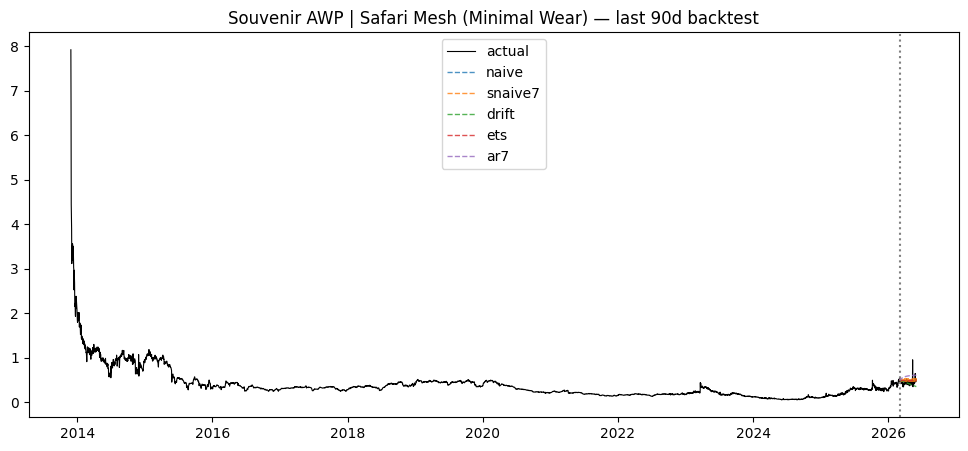

In [ ]:
target = sample[0]
df = get_daily(target).filter(pl.col("price") > 0)
n = df.height
cutoff = n - 90

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df["date"], df["price"], "k-", lw=0.8, label="actual")
for mname, fn in MODELS.items():
    pred = fn(df["price"].to_numpy()[:cutoff], 90)
    ax.plot(df["date"][cutoff:], pred, "--", lw=1, alpha=0.8, label=mname)
ax.axvline(df["date"][cutoff], color="gray", ls=":")
ax.set_title(f"{target} — last 90d backtest")
ax.legend()
plt.show()

## Conclusões

Olha a tabela em §5:
- Se `naive` em h=1 tiver MAPE <2-3%, qualquer modelo ML tem de bater isso por margem clara.
- Se a vantagem do `snaive7` sobre `naive` for grande, sazonalidade weekly é real → considerar features de dow.
- Se `ets`/`ar7` ganharem ao `drift` mas perderem ao `naive` em h=1 e ganharem em h=30 → o modelo precisa de horizonte.

Próximo passo: usar este harness para benchmarkar features (lagged returns, vol, dow, peer prices) num gradient-boosted ou modelo neuronal.